# Task 1: Tokenisation and EDA

This notebook is just for tokenisation, light parsing, and dataset EDA. No model is trained here.

We can see what the raw amplitude string looks like, what the diagram text looks like, how the bounded tokenisation works, and how the squared-amplitude target looks in both raw and factorized form.

## Quick Takeaways

- the dataset here contains `234` QCD tree-level samples and `360` QED tree-level samples
- bounded tokenisation makes the amplitude source much easier to handle without destroying the symbolic structure: QCD amplitude vocab drops from `6892 -> 694`, while QED drops from `3449 -> 198`
- the current bounded-tokenisation style is: `%gam_5702 -> %gam_INDEX_1`, `p_3 -> MOMENTUM_0`.
- factorized targets are much cleaner to inspect than the raw squared strings: QCD average target length drops from `326.49 -> 46.64` postfix tokens, while QED drops from `69.52 -> 42.70`
- the diagram text already carries enough structure to motivate the graph-style QCD view and the fixed-slot QED view
- one alternative tokenisation we may explore during the project is to split bounded index tokens into a base token plus a local slot token, for example `%gam_INDEX_7 -> %gam_INDEX , IDX_7` and `p_4_%\\rho_INDEX_12 -> p_4_%\\rho_INDEX , IDX_12`; this can reduce OOV pressure, but it also increases source-sequence length, so I am keeping the current shorter fused format for now
- another alternative tokenisation we may explore is number wrapping, for example `16/9 -> [NUM_START] [DIGIT_1] [DIGIT_6] / [DIGIT_9] [NUM_END]`; this can make numeric structure more compositional, but it also lengthens sequences so it is not considered currently

```text
raw amplitude
  -> literal-preserving token split
  -> bounded indices and momenta
  -> encoder source tokens

raw squared amplitude
  -> symbolic factorization
  -> <prefactor> | <numerator> | <denominator>
  -> short postfix decoder target
```

```text
QCD line  -> externals + vertices + propagator + channel -> compact graph-style view
QED line  -> 4 externals + 2 vertices + 1 propagator    -> fixed 7-slot interaction view
```


In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp
from IPython.display import display


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "dataset").exists():
            return candidate
    return cwd


REPO_ROOT = find_repo_root()
LOCAL_DATASET_DIR = REPO_ROOT / "dataset"
QCD_DATASET_DIR = Path("/kaggle/input/datasets/nextsmallestml/qcd-dataset")
QED_DATASET_DIR = Path("/kaggle/input/datasets/nextsmallestml/qed-dataset")

if not QCD_DATASET_DIR.exists():
    QCD_DATASET_DIR = LOCAL_DATASET_DIR
if not QED_DATASET_DIR.exists():
    QED_DATASET_DIR = LOCAL_DATASET_DIR

OUTPUT_DIR = REPO_ROOT / "outputs" / "common_task_1_2_tokenisation_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 240)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (8, 4)

print(f"Repo root: {REPO_ROOT}")
print(f"QCD dataset dir: {QCD_DATASET_DIR}")
print(f"QED dataset dir: {QED_DATASET_DIR}")
print(f"Output dir: {OUTPUT_DIR}")


Repo root: /kaggle/working
QCD dataset dir: /kaggle/input/datasets/nextsmallestml/qcd-dataset
QED dataset dir: /kaggle/input/datasets/nextsmallestml/qed-dataset
Output dir: /kaggle/working/outputs/common_task_1_2_tokenisation_eda


In [2]:
# ------------------------------------------------------------------
# Raw line parsing
# ------------------------------------------------------------------

def split_symba_sections(raw_line: str) -> dict[str, str]:
    raw = raw_line.strip()
    event_type, remainder = raw.split(":", 1)
    remainder = remainder.strip()

    interaction_end = remainder.find(" : Vertex")
    if interaction_end == -1:
        interaction_end = remainder.find(":Vertex")
    if interaction_end == -1:
        raise ValueError("Could not find interaction/topology boundary.")

    interaction_text = remainder[:interaction_end].strip()
    rest = remainder[interaction_end + 3 :].strip()

    v1_pos = rest.find("Vertex V_1")
    if v1_pos == -1:
        parts = rest.split(" : ", 2)
        topology_text = parts[0] if len(parts) > 0 else ""
        amplitude_text = parts[1] if len(parts) > 1 else ""
        squared_text = parts[2] if len(parts) > 2 else ""
    else:
        search_start = v1_pos + len("Vertex V_1")
        topology_end = rest.find(" : ", search_start)
        if topology_end == -1:
            raise ValueError("Could not find topology/amplitude boundary.")
        topology_text = rest[:topology_end].strip()
        amplitude_and_squared = rest[topology_end + 3 :].strip()
        last_colon = amplitude_and_squared.rfind(" : ")
        if last_colon == -1:
            raise ValueError("Could not find amplitude/squared boundary.")
        amplitude_text = amplitude_and_squared[:last_colon].strip()
        squared_text = amplitude_and_squared[last_colon + 3 :].strip()

    return {
        "event_type": event_type.strip(),
        "interaction_text": interaction_text,
        "topology_text": topology_text,
        "raw_diagram": f"{interaction_text} : {topology_text}",
        "raw_amplitude": amplitude_text,
        "raw_squared": squared_text,
    }


def load_symba_dataframe(dataset_dir: Path, pattern: str, theory: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    counts = []
    for path in sorted(dataset_dir.glob(pattern)):
        file_rows = []
        with open(path, encoding="utf-8") as handle:
            for raw_line in handle:
                if not raw_line.strip():
                    continue
                payload = split_symba_sections(raw_line)
                payload["source_file"] = path.name
                payload["theory"] = theory
                file_rows.append(payload)
        rows.extend(file_rows)
        counts.append({"theory": theory, "source_file": path.name, "num_samples": len(file_rows)})
    return pd.DataFrame(rows), pd.DataFrame(counts)


# ------------------------------------------------------------------
# Amplitude-side tokenisation from the amp2sq path
# ------------------------------------------------------------------

RAW_SOURCE_TOKEN_RE = re.compile(
    r"\d+/\d+"
    r"|\d+"
    r"|[A-Za-z%\\_][A-Za-z0-9%\\_]*"
    r"|[{}(),*+\-/^]"
)
RAW_INDEX_TOKEN_RE = re.compile(r"(.+)_([0-9]+)$")
RAW_MOMENTUM_TOKEN_RE = re.compile(r"p_\d+$")
RAW_MANDELSTAM_TOKEN_RE = re.compile(r"s_\d+$")
RAW_MASS_TOKEN_RE = re.compile(r"m_[A-Za-z]+$")


def normalize_raw_source_tokens(tokens: list[str], coupling_symbol: str) -> list[str]:
    normalized = []
    index_map = {}
    momentum_map = {}

    for token in tokens:
        if RAW_MOMENTUM_TOKEN_RE.fullmatch(token):
            mapped = momentum_map.setdefault(token, f"MOMENTUM_{len(momentum_map)}")
            normalized.append(mapped)
            continue

        if token in {coupling_symbol, "i", "reg_prop"} or RAW_MANDELSTAM_TOKEN_RE.fullmatch(token) or RAW_MASS_TOKEN_RE.fullmatch(token):
            normalized.append(token)
            continue

        match = RAW_INDEX_TOKEN_RE.fullmatch(token)
        if match is not None:
            prefix, _ = match.groups()
            mapped = index_map.setdefault(token, f"{prefix}_INDEX_{len(index_map)}")
            normalized.append(mapped)
            continue

        normalized.append(token)

    return normalized


def tokenize_raw_amplitude(raw_amplitude: str, coupling_symbol: str) -> list[str]:
    expr = re.sub(r"\s+", "", raw_amplitude.strip())
    if not expr:
        return []
    return normalize_raw_source_tokens(RAW_SOURCE_TOKEN_RE.findall(expr), coupling_symbol=coupling_symbol)


# ------------------------------------------------------------------
# Decoder-side symbolic tokenisation from the amp2sq path
# ------------------------------------------------------------------

ADD = "[ADD]"
SUB = "[SUB]"
MUL = "[MUL]"
DIV = "[DIV]"
POW = "[POW]"
NEG = "[NEG]"

BINARY_OPS = {ADD, SUB, MUL, DIV, POW}
UNARY_OPS = {NEG}
_TOKEN_RE = re.compile(r"\d+/\d+|[a-zA-Z_][a-zA-Z_0-9]*|\d+|[+\-*/^()]")
_OP_MAP = {"+": ADD, "-": SUB, "*": MUL, "/": DIV, "^": POW}


@dataclass
class LiteralNode:
    value: str


@dataclass
class VarNode:
    name: str


@dataclass
class BinOpNode:
    op: str
    left: object
    right: object


@dataclass
class UnaryNegNode:
    expr: object


class InfixParser:
    def __init__(self, tokens: list[str]):
        self.tokens = tokens
        self.pos = 0

    def peek(self):
        return self.tokens[self.pos] if self.pos < len(self.tokens) else None

    def consume(self):
        token = self.tokens[self.pos]
        self.pos += 1
        return token

    def expect(self, expected: str):
        token = self.consume()
        if token != expected:
            raise SyntaxError(f"Expected {expected}, got {token}")

    def parse(self):
        node = self.expr()
        if self.pos < len(self.tokens):
            raise SyntaxError(f"Unexpected trailing token {self.tokens[self.pos]}")
        return node

    def expr(self):
        node = self.term()
        while self.peek() in ("+", "-"):
            op = self.consume()
            node = BinOpNode(op, node, self.term())
        return node

    def term(self):
        node = self.power()
        while self.peek() in ("*", "/"):
            op = self.consume()
            node = BinOpNode(op, node, self.power())
        return node

    def power(self):
        node = self.unary()
        if self.peek() == "^":
            self.consume()
            node = BinOpNode("^", node, self.power())
        return node

    def unary(self):
        if self.peek() == "-":
            self.consume()
            return UnaryNegNode(self.unary())
        return self.atom()

    def atom(self):
        token = self.peek()
        if token is None:
            raise SyntaxError("Unexpected end of expression")
        if token == "(":
            self.consume()
            node = self.expr()
            self.expect(")")
            return node
        if token.isdigit() or is_rational_literal(token):
            self.consume()
            return LiteralNode(token)
        if token[0].isalpha() or token[0] == "_":
            self.consume()
            return VarNode(token)
        raise SyntaxError(f"Unexpected token {token}")


def is_rational_literal(token: str) -> bool:
    if token.count("/") != 1:
        return False
    numerator, denominator = token.split("/", 1)
    return numerator.isdigit() and denominator.isdigit()


def ast_to_postfix(node) -> list[str]:
    if isinstance(node, LiteralNode):
        return [node.value]
    if isinstance(node, VarNode):
        return [node.name]
    if isinstance(node, BinOpNode):
        return ast_to_postfix(node.left) + ast_to_postfix(node.right) + [_OP_MAP[node.op]]
    if isinstance(node, UnaryNegNode):
        return ast_to_postfix(node.expr) + [NEG]
    raise TypeError(f"Unknown node type: {type(node)}")


def infix_to_postfix(expr: str) -> list[str]:
    tokens = _TOKEN_RE.findall(expr)
    if not tokens:
        return []
    return ast_to_postfix(InfixParser(tokens).parse())


# ------------------------------------------------------------------
# Factorization from the amp2sq target path
# ------------------------------------------------------------------

QCD_MASS_NAMES = ("m_b", "m_c", "m_d", "m_s", "m_t", "m_u")
QED_MASS_NAMES = ("m_b", "m_c", "m_d", "m_e", "m_mu", "m_s", "m_t", "m_tt", "m_u")
MANDELSTAM_NAMES = ("s_12", "s_13", "s_14", "s_23", "s_24", "s_34")


def build_sympy_locals(coupling_symbol: str, mass_names: tuple[str, ...]):
    mass_symbols = {name: sp.symbols(name) for name in mass_names}
    mandelstam_symbols = {name: sp.symbols(name) for name in MANDELSTAM_NAMES}
    coupling = sp.symbols(coupling_symbol)
    reg_prop = sp.symbols("reg_prop")
    locals_map = {
        coupling_symbol: coupling,
        "i": sp.I,
        "reg_prop": reg_prop,
        **mass_symbols,
        **mandelstam_symbols,
    }
    symbol_order = tuple(mass_symbols[name] for name in mass_names) + tuple(mandelstam_symbols[name] for name in MANDELSTAM_NAMES) + (reg_prop,)
    return coupling, locals_map, symbol_order


def canonical_expr_string(expr: sp.Expr) -> str:
    return sp.sstr(expr, order="lex")


def canonicalize_numerator(expr: sp.Expr, symbol_order: tuple[sp.Symbol, ...]) -> sp.Expr:
    expanded = sp.expand(expr)
    try:
        poly = sp.Poly(expanded, *symbol_order, domain="ZZ")
        return sp.expand(poly.as_expr())
    except Exception:
        return sp.expand(expanded)


def factorize_squared_amplitude(raw_squared: str, theory: str) -> dict[str, object]:
    if theory == "QCD":
        coupling_symbol = "g"
        prefactor_name = "color_factor"
        mass_names = QCD_MASS_NAMES
    else:
        coupling_symbol = "e"
        prefactor_name = "charge_factor"
        mass_names = QED_MASS_NAMES

    coupling, locals_map, symbol_order = build_sympy_locals(coupling_symbol, mass_names)
    raw_string = raw_squared.replace("**", "^").strip()
    expr = sp.sympify(raw_string.replace("^", "**"), locals=locals_map)
    expr = sp.cancel(expr)

    numerator, denominator = sp.fraction(expr)
    denominator = sp.factor(denominator)
    den_const, denominator = denominator.as_coeff_Mul()

    numerator = sp.simplify(sp.collect(numerator, coupling**4) / (coupling**4))
    num_const, numerator = numerator.as_content_primitive()
    prefactor = sp.simplify(num_const / den_const)

    if prefactor.could_extract_minus_sign():
        prefactor = -prefactor
        numerator = -numerator

    prefactor = sp.nsimplify(prefactor)
    denominator = sp.factor(denominator)
    numerator = canonicalize_numerator(sp.simplify(numerator), symbol_order)

    prefactor_str = canonical_expr_string(prefactor)
    denominator_str = canonical_expr_string(denominator)
    numerator_infix = canonical_expr_string(numerator).replace("**", "^")
    factorized_full = f"({prefactor_str})*(({numerator_infix})/({denominator_str.replace('**', '^')}))"

    return {
        prefactor_name: prefactor_str,
        "denominator": denominator_str.replace("**", "^"),
        "numerator": numerator_infix,
        "factorized_full": factorized_full,
        "raw_string": raw_string,
        "factorized_postfix": infix_to_postfix(factorized_full),
        "raw_postfix": infix_to_postfix(raw_string),
        "coupling_note": f"common {coupling_symbol}^4 stripped" if theory == "QCD" else f"common {coupling_symbol}^4 stripped",
    }


# ------------------------------------------------------------------
# Lightweight diagram parsing for display
# ------------------------------------------------------------------

QCD_EXTERNAL_RE = re.compile(
    r"(AntiPart\s+)?(\w+)_\{([^,}]+),([^}]+)\}\(X\)(\^\(\*\))?"
)
QED_EXTERNAL_RE = re.compile(
    r"(AntiPart\s+)?([A-Za-z]+)_([^\s()]+)\(X\)(\^\(\*\))?"
)
VERTEX_RE = re.compile(r"Vertex\s+V_(\d+)\s*:")
LEG_RE = re.compile(r"(AntiPart\s+)?(OffShell\s+)?(\w+)\(([^)]+)\)")


def infer_channel(vertices_df: pd.DataFrame, incoming_momenta: set[int]) -> str:
    if len(vertices_df) < 2:
        return "unknown"
    v0_legs = set(vertices_df.iloc[0]["external_momenta"])
    v1_legs = set(vertices_df.iloc[1]["external_momenta"])
    if incoming_momenta <= v0_legs or incoming_momenta <= v1_legs:
        return "s"
    if (1 in v0_legs and 3 in v0_legs) or (1 in v1_legs and 3 in v1_legs):
        return "t"
    if (1 in v0_legs and 4 in v0_legs) or (1 in v1_legs and 4 in v1_legs):
        return "u"
    return "unknown"


def parse_topology(topology_text: str) -> tuple[pd.DataFrame, dict[str, object]]:
    vertex_rows = []
    propagator_row = None
    blocks = VERTEX_RE.split(topology_text)
    idx = 1
    while idx < len(blocks) - 1:
        vertex_id = int(blocks[idx])
        content = blocks[idx + 1]
        idx += 2
        external_momenta = []
        for anti, offshell, flavor, location in LEG_RE.findall(content):
            if offshell:
                mention_vertex = int(re.search(r"V_(\d+)", location).group(1)) if re.search(r"V_(\d+)", location) else vertex_id
                propagator_row = {
                    "flavor": flavor,
                    "is_antiparticle": bool(anti),
                    "mentions_vertex": mention_vertex,
                }
                continue
            match = re.search(r"X_(\d+)", location)
            if match:
                external_momenta.append(int(match.group(1)))
        vertex_rows.append({
            "vertex_id": vertex_id,
            "external_momenta": tuple(sorted(external_momenta)),
            "num_external_legs": len(external_momenta),
        })
    return pd.DataFrame(vertex_rows).sort_values("vertex_id").reset_index(drop=True), propagator_row or {}


def parse_qcd_diagram(row: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    externals = []
    momentum = 1
    for group_idx, group in enumerate(re.split(r"\s+to\s+", row["interaction_text"].replace("Interaction:", "").strip())):
        is_incoming = group_idx == 0
        for anti, flavor, color_label, spinor_label, conjugate in QCD_EXTERNAL_RE.findall(group):
            externals.append({
                "momentum": momentum,
                "direction": "in" if is_incoming else "out",
                "flavor": flavor,
                "is_antiparticle": bool(anti),
                "color_label": color_label,
                "spinor_label": spinor_label,
                "is_conjugate": bool(conjugate),
            })
            momentum += 1
    externals_df = pd.DataFrame(externals)
    vertices_df, propagator = parse_topology(row["topology_text"])
    channel = infer_channel(vertices_df, set(externals_df.loc[externals_df["direction"] == "in", "momentum"]))
    summary_df = pd.DataFrame([
        {
            "propagator_flavor": propagator.get("flavor", "unknown"),
            "propagator_type": "gluon" if propagator.get("flavor") == "G" else "quark",
            "channel": channel,
            "num_vertices": len(vertices_df),
        }
    ])
    return externals_df, vertices_df, summary_df


QED_CHARGE_MAP = {
    "e": -1,
    "mu": -1,
    "tau": -1,
    "u": sp.Rational(2, 3),
    "c": sp.Rational(2, 3),
    "t": sp.Rational(2, 3),
    "d": sp.Rational(-1, 3),
    "s": sp.Rational(-1, 3),
    "b": sp.Rational(-1, 3),
    "A": 0,
}


def signed_charge(flavor: str, is_antiparticle: bool):
    charge = QED_CHARGE_MAP.get(flavor, "?")
    if charge == "?" or charge == 0:
        return charge
    return -charge if is_antiparticle else charge


def qed_process_family(externals_df: pd.DataFrame) -> str:
    photon_count = int((externals_df["flavor"] == "A").sum())
    if photon_count == 4:
        return "photon-photon"
    if photon_count == 0:
        return "fermion-fermion"
    return "mixed"


def parse_qed_diagram(row: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    externals = []
    momentum = 1
    for group_idx, group in enumerate(re.split(r"\s+to\s+", row["interaction_text"].replace("Interaction:", "").strip())):
        is_incoming = group_idx == 0
        for anti, flavor, label, conjugate in QED_EXTERNAL_RE.findall(group):
            externals.append({
                "slot": momentum - 1,
                "momentum": momentum,
                "direction": "in" if is_incoming else "out",
                "flavor": flavor,
                "is_antiparticle": bool(anti),
                "label": label,
                "is_conjugate": bool(conjugate),
                "signed_charge": signed_charge(flavor, bool(anti)),
            })
            momentum += 1
    externals_df = pd.DataFrame(externals)
    vertices_df, propagator = parse_topology(row["topology_text"])
    channel = infer_channel(vertices_df, set(externals_df.loc[externals_df["direction"] == "in", "momentum"]))
    pattern = (
        "in: " + ", ".join(f"{row['flavor']}{'_bar' if row['is_antiparticle'] else ''}" for _, row in externals_df.loc[externals_df["direction"] == "in"].iterrows())
        + " -> out: " + ", ".join(f"{row['flavor']}{'_bar' if row['is_antiparticle'] else ''}" for _, row in externals_df.loc[externals_df["direction"] == "out"].iterrows())
    )
    summary_df = pd.DataFrame([
        {
            "propagator_flavor": propagator.get("flavor", "unknown"),
            "channel": channel,
            "process_family": qed_process_family(externals_df),
            "external_pattern": pattern,
        }
    ])
    return externals_df, vertices_df, summary_df


# ------------------------------------------------------------------
# Dataset augmentation helpers for the notebook
# ------------------------------------------------------------------

def enrich_dataframe(df: pd.DataFrame, theory: str) -> pd.DataFrame:
    coupling_symbol = "g" if theory == "QCD" else "e"
    enriched = df.copy()
    enriched["raw_amplitude_tokens"] = enriched["raw_amplitude"].map(lambda value: RAW_SOURCE_TOKEN_RE.findall(re.sub(r"\s+", "", value.strip())))
    enriched["bounded_amplitude_tokens"] = enriched["raw_amplitude"].map(lambda value: tokenize_raw_amplitude(value, coupling_symbol=coupling_symbol))
    enriched["raw_squared_postfix_tokens"] = enriched["raw_squared"].map(lambda value: infix_to_postfix(value.replace("**", "^")))
    enriched["factorized_payload"] = enriched["raw_squared"].map(lambda value: factorize_squared_amplitude(value, theory=theory))
    enriched["factorized_postfix_tokens"] = enriched["factorized_payload"].map(lambda payload: payload["factorized_postfix"])
    return enriched


def top_vocab_table(token_sequences: pd.Series, top_n: int = 20) -> pd.DataFrame:
    counter = Counter()
    for tokens in token_sequences:
        counter.update(tokens)
    return pd.DataFrame(counter.most_common(top_n), columns=["token", "count"])


def vocab_size(token_sequences: pd.Series) -> int:
    counter = Counter()
    for tokens in token_sequences:
        counter.update(tokens)
    return len(counter)


def length_stats(df: pd.DataFrame, theory: str) -> pd.DataFrame:
    rows = []
    views = {
        "diagram_chars": df["raw_diagram"].map(len),
        "amplitude_chars": df["raw_amplitude"].map(len),
        "squared_chars": df["raw_squared"].map(len),
        "bounded_amplitude_tokens": df["bounded_amplitude_tokens"].map(len),
        "raw_squared_postfix_tokens": df["raw_squared_postfix_tokens"].map(len),
        "factorized_postfix_tokens": df["factorized_postfix_tokens"].map(len),
    }
    for view, values in views.items():
        rows.append({
            "theory": theory,
            "view": view,
            "min": int(values.min()),
            "avg": round(float(values.mean()), 2),
            "max": int(values.max()),
        })
    return pd.DataFrame(rows)


## Read The Dataset

I first split each SYMBA line into four parts: the interaction text, the topology text, the raw amplitude, and the raw squared amplitude. For this notebook I keep both QCD and QED in one place so it is easy to compare them.


In [3]:
qcd_df, qcd_counts = load_symba_dataframe(QCD_DATASET_DIR, "QCD-2-to-2-diag-TreeLevel-*.txt", theory="QCD")
qed_df, qed_counts = load_symba_dataframe(QED_DATASET_DIR, "QED-2-to-2-diag-TreeLevel-*.txt", theory="QED")

print(f"QCD samples: {len(qcd_df)}")
print(f"QED samples: {len(qed_df)}")

print("\nQCD counts by file")
display(qcd_counts)
print("\nQED counts by file")
display(qed_counts)

preview_columns = [
    "theory",
    "source_file",
    "raw_diagram",
    "raw_amplitude",
    "raw_squared",
]
preview_frames = [frame.head(1) for frame in (qcd_df, qed_df) if not frame.empty]
combined_preview = pd.concat(preview_frames, ignore_index=True)[preview_columns] if preview_frames else pd.DataFrame(columns=preview_columns)
print("\nOne raw sample from each theory")
display(combined_preview)


QCD samples: 234
QED samples: 360

QCD counts by file


,theory,source_file,num_samples
0,QCD,QCD-2-to-2-diag-TreeLevel-0.txt,46
1,QCD,QCD-2-to-2-diag-TreeLevel-1.txt,42
2,QCD,QCD-2-to-2-diag-TreeLevel-2.txt,38
3,QCD,QCD-2-to-2-diag-TreeLevel-3.txt,34
4,QCD,QCD-2-to-2-diag-TreeLevel-4.txt,30
5,QCD,QCD-2-to-2-diag-TreeLevel-5.txt,26
6,QCD,QCD-2-to-2-diag-TreeLevel-6.txt,18



QED counts by file


,theory,source_file,num_samples
0,QED,QED-2-to-2-diag-TreeLevel-0.txt,54
1,QED,QED-2-to-2-diag-TreeLevel-1.txt,50
2,QED,QED-2-to-2-diag-TreeLevel-2.txt,46
3,QED,QED-2-to-2-diag-TreeLevel-3.txt,42
4,QED,QED-2-to-2-diag-TreeLevel-4.txt,38
5,QED,QED-2-to-2-diag-TreeLevel-5.txt,34
6,QED,QED-2-to-2-diag-TreeLevel-6.txt,30
7,QED,QED-2-to-2-diag-TreeLevel-7.txt,26
8,QED,QED-2-to-2-diag-TreeLevel-8.txt,22
9,QED,QED-2-to-2-diag-TreeLevel-9.txt,18



One raw sample from each theory


,theory,source_file,raw_diagram,raw_amplitude,raw_squared
0,QCD,QCD-2-to-2-diag-TreeLevel-0.txt,"u_{G_49,eps_42}(X)^(*) AntiPart u_{H_65,eta_102}(X) to d_{A_74,alpha_104}(X) AntiPart d_{B_74,beta_44}(X)^(*) : Vertex V_1:d(X_3), AntiPart d(X_4), OffShell G(V_1), Vertex V_0:u(X_1), AntiPart u(X_2), OffShell G(V_0),","-1/4*i*g^2*gamma_{+%\sigma_189,%gam_115,%del_115}*gamma_{%\sigma_189,%gam_116,%del_116}*(d_{j_31,%C_55,%gam_115}(p_3)_u^(*)*d_{k_31,%D_68,%del_115}(p_4)_v*u_{l_29,%C_55,%del_116}(p_1)_u*u_{i_31,%D_68,%gam_116}(p_2)_v^(*) + -1/3*d_{j_31,...",-1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2*reg_prop)^(-2) + 1/16*i*g^2*(i*g^2*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_...
1,QED,QED-2-to-2-diag-TreeLevel-0.txt,"e_eps_60(X)^(*) AntiPart e_eta_138(X) to mu_alpha_141(X) AntiPart mu_beta_63(X)^(*) : Vertex V_1:mu(X_3), AntiPart mu(X_4), OffShell A(V_1), Vertex V_0:e(X_1), AntiPart e(X_2), OffShell A(V_0),","-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43,%gam_166}(p_2)_v^(*)*mu_{i_45,%gam_165}(p_3)_u^(*)*mu_{j_45,%del_165}(p_4)_v/(m_e^2 + s_12 + 1/2*reg_prop)",1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_e^2*s_34)*(m_e^2 + s_12 + 1/2*reg_prop)^(-2)


## Basic EDA

Now I run the same lightweight tokenisation and factorized-target construction across the full corpus. This is the part that helps us see how long the strings really are before any model ever sees them.

The main comparisons I want to make explicit are:

- source vocab compression: QCD `6892 -> 694`, QED `3449 -> 198`
- target sequence shortening after factorization: QCD `326.49 -> 46.64` postfix tokens on average, QED `69.52 -> 42.70`
- source length scale gap: QCD bounded source averages `429.72` tokens, while QED averages `120.87`


,theory,view,min,avg,max
0,QCD,diagram_chars,193,229.84,275
1,QCD,amplitude_chars,370,1257.85,4734
2,QCD,squared_chars,195,756.53,2872
3,QCD,bounded_amplitude_tokens,164,429.72,1802
4,QCD,raw_squared_postfix_tokens,84,326.49,1224
5,QCD,factorized_postfix_tokens,39,46.64,66
6,QED,diagram_chars,161,200.30,243
7,QED,amplitude_chars,217,332.89,517
8,QED,squared_chars,117,154.21,210
9,QED,bounded_amplitude_tokens,90,120.87,175


,theory,raw_amplitude_vocab,bounded_amplitude_vocab,raw_squared_postfix_vocab,factorized_postfix_vocab
0,QCD,6892,694,84,29
1,QED,3449,198,39,32


,theory,raw_amplitude_vocab,bounded_amplitude_vocab,raw_squared_postfix_vocab,factorized_postfix_vocab,bounded_source_avg_len,factorized_target_avg_len,raw_target_avg_len,source_vocab_drop_pct,target_length_drop_pct
0,QCD,6892,694,84,29,429.72,46.64,326.49,89.93,85.71
1,QED,3449,198,39,32,120.87,42.70,69.52,94.26,38.58


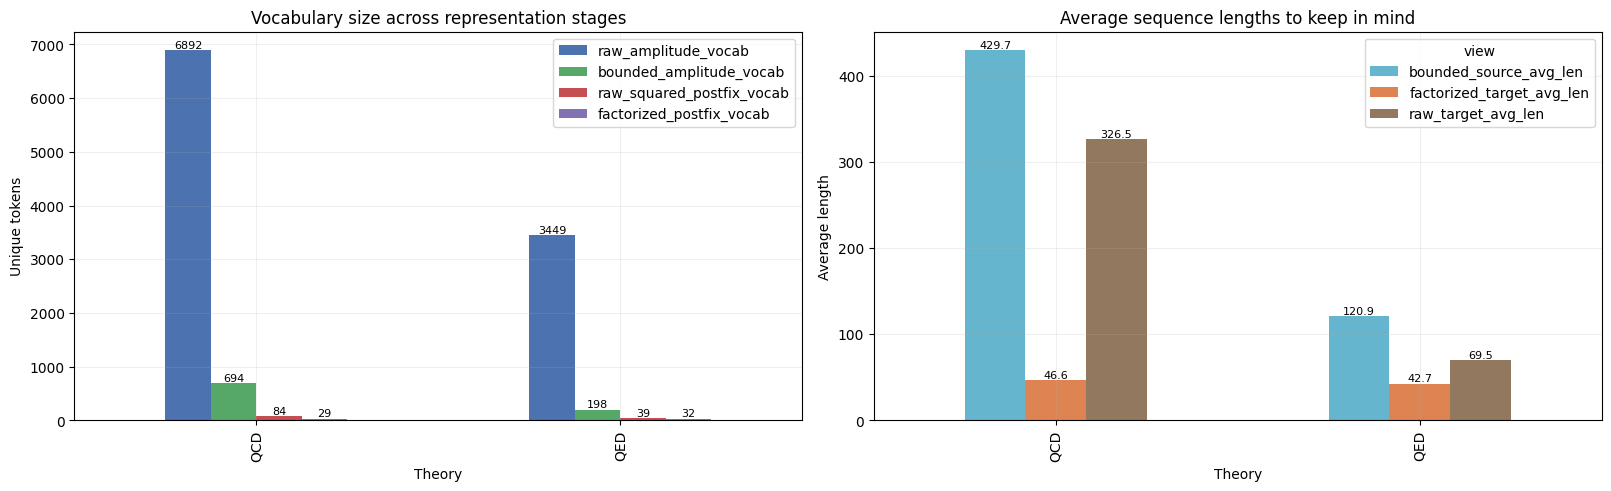

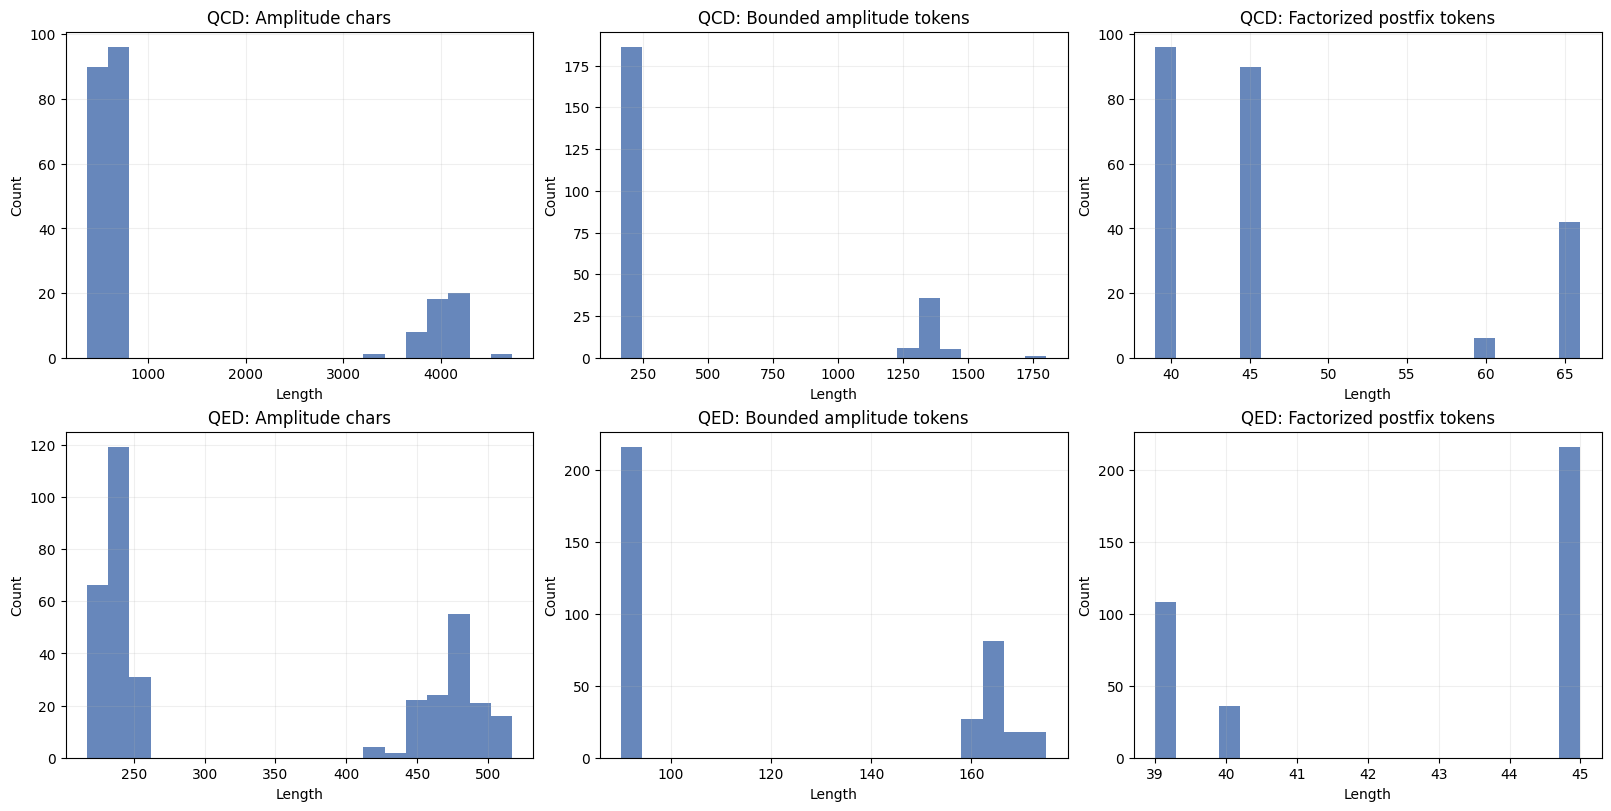

Top bounded-amplitude tokens (QCD)


,token,count
0,",",14344
1,*,11714
2,{,7172
3,},7172
4,(,6900
5,),6900
6,+,3114
7,^,2424
8,T_C_10_,1748
9,G_,1748


Top bounded-amplitude tokens (QED)


,token,count
0,*,5358
1,",",4032
2,(,3546
3,),3546
4,{,3024
5,},3024
6,+,1656
7,^,1584
8,gamma_,1008
9,_u,720


Top factorized target tokens (QCD)


,token,count
0,[MUL],2292
1,2,1986
2,[POW],1350
3,[ADD],870
4,[SUB],576
5,s_13,414
6,s_14,384
7,s_34,378
8,reg_prop,234
9,[DIV],234


Top factorized target tokens (QED)


,token,count
0,[MUL],3096
1,2,2952
2,[POW],2016
3,[ADD],1242
4,[SUB],774
5,s_13,486
6,s_14,468
7,s_34,450
8,s_12,360
9,reg_prop,360


In [4]:
qcd_enriched = enrich_dataframe(qcd_df, theory="QCD")
qed_enriched = enrich_dataframe(qed_df, theory="QED")

length_summary_df = pd.concat([
    length_stats(qcd_enriched, theory="QCD"),
    length_stats(qed_enriched, theory="QED"),
], ignore_index=True)

display(length_summary_df)

vocab_summary_df = pd.DataFrame([
    {
        "theory": "QCD",
        "raw_amplitude_vocab": vocab_size(qcd_enriched["raw_amplitude_tokens"]),
        "bounded_amplitude_vocab": vocab_size(qcd_enriched["bounded_amplitude_tokens"]),
        "raw_squared_postfix_vocab": vocab_size(qcd_enriched["raw_squared_postfix_tokens"]),
        "factorized_postfix_vocab": vocab_size(qcd_enriched["factorized_postfix_tokens"]),
    },
    {
        "theory": "QED",
        "raw_amplitude_vocab": vocab_size(qed_enriched["raw_amplitude_tokens"]),
        "bounded_amplitude_vocab": vocab_size(qed_enriched["bounded_amplitude_tokens"]),
        "raw_squared_postfix_vocab": vocab_size(qed_enriched["raw_squared_postfix_tokens"]),
        "factorized_postfix_vocab": vocab_size(qed_enriched["factorized_postfix_tokens"]),
    },
])
display(vocab_summary_df)

avg_length_df = (
    length_summary_df[length_summary_df["view"].isin(["bounded_amplitude_tokens", "raw_squared_postfix_tokens", "factorized_postfix_tokens"])]
    .pivot(index="theory", columns="view", values="avg")
    .rename(columns={
        "bounded_amplitude_tokens": "bounded_source_avg_len",
        "raw_squared_postfix_tokens": "raw_target_avg_len",
        "factorized_postfix_tokens": "factorized_target_avg_len",
    })
    .reset_index()
)

compression_summary_df = vocab_summary_df.merge(avg_length_df, on="theory")
compression_summary_df["source_vocab_drop_pct"] = (
    100 * (1 - compression_summary_df["bounded_amplitude_vocab"] / compression_summary_df["raw_amplitude_vocab"])
).round(2)
compression_summary_df["target_length_drop_pct"] = (
    100 * (1 - compression_summary_df["factorized_target_avg_len"] / compression_summary_df["raw_target_avg_len"])
).round(2)
display(compression_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), constrained_layout=True)
vocab_summary_df.set_index("theory").plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"],
)
axes[0].set_title("Vocabulary size across representation stages")
axes[0].set_xlabel("Theory")
axes[0].set_ylabel("Unique tokens")
axes[0].grid(alpha=0.2)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", fontsize=8)

avg_length_df.set_index("theory").plot(
    kind="bar",
    ax=axes[1],
    color=["#64B5CD", "#DD8452", "#937860"],
)
axes[1].set_title("Average sequence lengths to keep in mind")
axes[1].set_xlabel("Theory")
axes[1].set_ylabel("Average length")
axes[1].grid(alpha=0.2)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", fontsize=8)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
plot_specs = [
    ("raw_amplitude", "Amplitude chars"),
    ("bounded_amplitude_tokens", "Bounded amplitude tokens"),
    ("factorized_postfix_tokens", "Factorized postfix tokens"),
]
for row_idx, (label, df) in enumerate([("QCD", qcd_enriched), ("QED", qed_enriched)]):
    for col_idx, (column, title) in enumerate(plot_specs):
        values = df[column].map(len) if column.endswith("tokens") else df[column].map(len)
        axes[row_idx, col_idx].hist(values, bins=20, color="#4C72B0", alpha=0.85)
        axes[row_idx, col_idx].set_title(f"{label}: {title}")
        axes[row_idx, col_idx].set_xlabel("Length")
        axes[row_idx, col_idx].set_ylabel("Count")
        axes[row_idx, col_idx].grid(alpha=0.2)
plt.show()

print("Top bounded-amplitude tokens (QCD)")
display(top_vocab_table(qcd_enriched["bounded_amplitude_tokens"], top_n=20))
print("Top bounded-amplitude tokens (QED)")
display(top_vocab_table(qed_enriched["bounded_amplitude_tokens"], top_n=20))
print("Top factorized target tokens (QCD)")
display(top_vocab_table(qcd_enriched["factorized_postfix_tokens"], top_n=20))
print("Top factorized target tokens (QED)")
display(top_vocab_table(qed_enriched["factorized_postfix_tokens"], top_n=20))


## Amplitude Tokenisation

This part is deliberately simple. I take one raw amplitude string, split it into literal-preserving tokens, and then apply the bounded index/momentum normalisation used in the active amp2sq setup.

Sample-specific indices and momenta gets compressed.

```text
raw amplitude string
  -> raw token list
  -> bounded token list with local placeholders
  -> shorter reusable source vocabulary
```


In [5]:
def amplitude_example_table(row: pd.Series, theory: str) -> pd.DataFrame:
    payload = row["factorized_payload"]
    return pd.DataFrame([
        {
            "theory": theory,
            "raw_amplitude": row["raw_amplitude"],
            "raw_token_list": row["raw_amplitude_tokens"],
            "bounded_token_list": row["bounded_amplitude_tokens"],
            "example_output_postfix": payload["factorized_postfix"][:40],
        }
    ])


print("QCD amplitude tokenisation example")
display(amplitude_example_table(qcd_enriched.iloc[0], theory="QCD"))
print("QED amplitude tokenisation example")
display(amplitude_example_table(qed_enriched.iloc[0], theory="QED"))


QCD amplitude tokenisation example


,theory,raw_amplitude,raw_token_list,bounded_token_list,example_output_postfix
0,QCD,"-1/4*i*g^2*gamma_{+%\sigma_189,%gam_115,%del_115}*gamma_{%\sigma_189,%gam_116,%del_116}*(d_{j_31,%C_55,%gam_115}(p_3)_u^(*)*d_{k_31,%D_68,%del_115}(p_4)_v*u_{l_29,%C_55,%del_116}(p_1)_u*u_{i_31,%D_68,%gam_116}(p_2)_v^(*) + -1/3*d_{j_31,...","[-, 1/4, *, i, *, g, ^, 2, *, gamma_, {, +, %\sigma_189, ,, %gam_115, ,, %del_115, }, *, gamma_, {, %\sigma_189, ,, %gam_116, ,, %del_116, }, *, (, d_, {, j_31, ,, %C_55, ,, %gam_115, }, (, p_3, ), _u, ^, (, *, ), *, d_, {, k_31, ,, %D_...","[-, 1/4, *, i, *, g, ^, 2, *, gamma_, {, +, %\sigma_INDEX_0, ,, %gam_INDEX_1, ,, %del_INDEX_2, }, *, gamma_, {, %\sigma_INDEX_0, ,, %gam_INDEX_3, ,, %del_INDEX_4, }, *, (, d_, {, j_INDEX_5, ,, %C_INDEX_6, ,, %gam_INDEX_1, }, (, MOMENTUM...","[16/9, 2, m_d, 2, [POW], [MUL], m_u, 2, [POW], [MUL], m_d, 2, [POW], s_12, [MUL], [ADD], m_u, 2, [POW], s_34, [MUL], [ADD], s_13, s_24, [MUL], [ADD], s_14, s_23, [MUL], [ADD], 2, m_u, 2, [POW], [MUL], reg_prop, [ADD], 2, s_12, [MUL]]"


QED amplitude tokenisation example


,theory,raw_amplitude,raw_token_list,bounded_token_list,example_output_postfix
0,QED,"-1/2*i*e^2*gamma_{+%\sigma_249,%gam_165,%del_165}*gamma_{%\sigma_249,%gam_166,%del_166}*e_{k_43,%del_166}(p_1)_u*e_{l_43,%gam_166}(p_2)_v^(*)*mu_{i_45,%gam_165}(p_3)_u^(*)*mu_{j_45,%del_165}(p_4)_v/(m_e^2 + s_12 + 1/2*reg_prop)","[-, 1/2, *, i, *, e, ^, 2, *, gamma_, {, +, %\sigma_249, ,, %gam_165, ,, %del_165, }, *, gamma_, {, %\sigma_249, ,, %gam_166, ,, %del_166, }, *, e_, {, k_43, ,, %del_166, }, (, p_1, ), _u, *, e_, {, l_43, ,, %gam_166, }, (, p_2, ), _v, ...","[-, 1/2, *, i, *, e, ^, 2, *, gamma_, {, +, %\sigma_INDEX_0, ,, %gam_INDEX_1, ,, %del_INDEX_2, }, *, gamma_, {, %\sigma_INDEX_0, ,, %gam_INDEX_3, ,, %del_INDEX_4, }, *, e_, {, k_INDEX_5, ,, %del_INDEX_4, }, (, MOMENTUM_0, ), _u, *, e_, ...","[8, 2, m_e, 2, [POW], [MUL], m_mu, 2, [POW], [MUL], m_e, 2, [POW], s_34, [MUL], [ADD], m_mu, 2, [POW], s_12, [MUL], [ADD], s_13, s_24, [MUL], [ADD], s_14, s_23, [MUL], [ADD], 2, m_e, 2, [POW], [MUL], reg_prop, [ADD], 2, s_12, [MUL]]"


## Diagram Representation

This is the part I want to highlight a bit more. The raw diagram text is not just decoration; it already tells us a lot about the physics structure.

For QCD I show a compact graph-style summary built from the external legs, the two vertices, the propagator, and the inferred channel. For QED I show the same idea in the fixed-slot interaction view.

```text
QCD diagram text
  -> external legs
  -> 2 vertices
  -> propagator
  -> s / t / u channel

QED diagram text
  -> 4 external slots
  -> 2 vertex slots
  -> 1 propagator slot
  -> fixed 7-slot interaction template
```


In [6]:
qcd_example = qcd_enriched.iloc[0]
qed_example = qed_enriched.iloc[0]

qcd_externals_df, qcd_vertices_df, qcd_summary_df = parse_qcd_diagram(qcd_example)
qed_externals_df, qed_vertices_df, qed_summary_df = parse_qed_diagram(qed_example)

print("QCD raw diagram")
print(qcd_example["raw_diagram"])
print("\nQCD externals")
display(qcd_externals_df)
print("QCD vertices")
display(qcd_vertices_df)
print("QCD compact graph summary")
display(qcd_summary_df)

print("QED raw diagram")
print(qed_example["raw_diagram"])
print("\nQED fixed 7-slot interaction view: external slots")
display(qed_externals_df)
print("QED vertex slots")
display(qed_vertices_df)
print("QED interaction summary")
display(qed_summary_df)


QCD raw diagram
u_{G_49,eps_42}(X)^(*)  AntiPart u_{H_65,eta_102}(X)  to  d_{A_74,alpha_104}(X)  AntiPart d_{B_74,beta_44}(X)^(*) : Vertex V_1:d(X_3), AntiPart d(X_4),  OffShell G(V_1), Vertex V_0:u(X_1), AntiPart u(X_2),  OffShell G(V_0),

QCD externals


,momentum,direction,flavor,is_antiparticle,color_label,spinor_label,is_conjugate
0,1,in,u,False,G_49,eps_42,True
1,2,in,u,True,H_65,eta_102,False
2,3,out,d,False,A_74,alpha_104,False
3,4,out,d,True,B_74,beta_44,True


QCD vertices


,vertex_id,external_momenta,num_external_legs
0,0,"(1, 2)",2
1,1,"(3, 4)",2


QCD compact graph summary


...

,slot,momentum,direction,flavor,is_antiparticle,label,is_conjugate,signed_charge
0,0,1,in,e,False,eps_60,True,-1
1,1,2,in,e,True,eta_138,False,1
2,2,3,out,mu,False,alpha_141,False,-1
3,3,4,out,mu,True,beta_63,True,1


QED vertex slots


,vertex_id,external_momenta,num_external_legs
0,0,"(1, 2)",2
1,1,"(3, 4)",2


QED interaction summary


,propagator_flavor,channel,process_family,external_pattern
0,A,s,fermion-fermion,"in: e, e_bar -> out: mu, mu_bar"


## Factorized vs Unfactorized Output

After the basic tokenisation story, this is the second new piece I wanted to make visible.

The raw squared amplitude is the direct symbolic target. The factorized target rewrites the same object into a cleaner prefactor/numerator/denominator form. In the current modeling setup I also strip the universal coupling factor (`g^4` for QCD, `e^4` for QED), since it is common across the audited corpus.

This factorized view is also useful because it exposes closed sets on the target side, such as denominator classes and color-factor or charge-factor classes.

```text
raw squared expression
  -> cancel and factor symbolically
  -> split into prefactor + numerator + denominator
  -> serialize as a much shorter postfix target
```


In [7]:
def output_example_table(row: pd.Series, theory: str) -> pd.DataFrame:
    payload = row["factorized_payload"]
    prefactor_key = "color_factor" if theory == "QCD" else "charge_factor"
    return pd.DataFrame([
        {
            "theory": theory,
            prefactor_key: payload[prefactor_key],
            "denominator": payload["denominator"],
            "numerator": payload["numerator"],
            "factorized_full": payload["factorized_full"],
            "raw_squared": payload["raw_string"],
            "factorized_postfix_tokens": payload["factorized_postfix"],
            "raw_postfix_tokens": payload["raw_postfix"],
            "note": payload["coupling_note"],
        }
    ])


def factor_class_summary(df: pd.DataFrame, theory: str) -> pd.DataFrame:
    payload_df = pd.DataFrame(df["factorized_payload"].tolist())
    prefactor_key = "color_factor" if theory == "QCD" else "charge_factor"
    return pd.DataFrame([
        {
            "theory": theory,
            "unique_denominator_classes": payload_df["denominator"].nunique(),
            f"unique_{prefactor_key}_classes": payload_df[prefactor_key].nunique(),
            "unique_factorized_targets": payload_df["factorized_full"].nunique(),
        }
    ])


print("QCD output example")
display(output_example_table(qcd_example, theory="QCD"))
print("QED output example")
display(output_example_table(qed_example, theory="QED"))

print("Closed-set summary on the factorized side")
display(pd.concat([
    factor_class_summary(qcd_enriched, theory="QCD"),
    factor_class_summary(qed_enriched, theory="QED"),
], ignore_index=True))


QCD output example


,theory,color_factor,denominator,numerator,factorized_full,raw_squared,factorized_postfix_tokens,raw_postfix_tokens,note
0,QCD,16/9,(2*m_u^2 + reg_prop + 2*s_12)^2,2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23,(16/9)*((2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23)/((2*m_u^2 + reg_prop + 2*s_12)^2)),-1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2*reg_prop)^(-2) + 1/16*i*g^2*(i*g^2*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_...,"[16/9, 2, m_d, 2, [POW], [MUL], m_u, 2, [POW], [MUL], m_d, 2, [POW], s_12, [MUL], [ADD], m_u, 2, [POW], s_34, [MUL], [ADD], s_13, s_24, [MUL], [ADD], s_14, s_23, [MUL], [ADD], 2, m_u, 2, [POW], [MUL], reg_prop, [ADD], 2, s_12, [MUL], [A...","[1/144, [NEG], g, 4, [POW], [MUL], 16, [NEG], m_d, 2, [POW], [MUL], m_u, 2, [POW], [MUL], 8, [NEG], m_d, 2, [POW], [MUL], s_12, [MUL], [ADD], 8, [NEG], s_14, [MUL], s_23, [MUL], [ADD], 8, [NEG], s_13, [MUL], s_24, [MUL], [ADD], 8, [NEG]...",common g^4 stripped


QED output example


,theory,charge_factor,denominator,numerator,factorized_full,raw_squared,factorized_postfix_tokens,raw_postfix_tokens,note
0,QED,8,(2*m_e^2 + reg_prop + 2*s_12)^2,2*m_e^2*m_mu^2 + m_e^2*s_34 + m_mu^2*s_12 + s_13*s_24 + s_14*s_23,(8)*((2*m_e^2*m_mu^2 + m_e^2*s_34 + m_mu^2*s_12 + s_13*s_24 + s_14*s_23)/((2*m_e^2 + reg_prop + 2*s_12)^2)),1/4*e^4*(16*m_e^2*m_mu^2 + 8*m_mu^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_e^2*s_34)*(m_e^2 + s_12 + 1/2*reg_prop)^(-2),"[8, 2, m_e, 2, [POW], [MUL], m_mu, 2, [POW], [MUL], m_e, 2, [POW], s_34, [MUL], [ADD], m_mu, 2, [POW], s_12, [MUL], [ADD], s_13, s_24, [MUL], [ADD], s_14, s_23, [MUL], [ADD], 2, m_e, 2, [POW], [MUL], reg_prop, [ADD], 2, s_12, [MUL], [AD...","[1/4, e, 4, [POW], [MUL], 16, m_e, 2, [POW], [MUL], m_mu, 2, [POW], [MUL], 8, m_mu, 2, [POW], [MUL], s_12, [MUL], [ADD], 8, s_14, [MUL], s_23, [MUL], [ADD], 8, s_13, [MUL], s_24, [MUL], [ADD], 8, m_e, 2, [POW], [MUL], s_34, [MUL], [ADD]...",common e^4 stripped


Closed-set summary on the factorized side


,theory,unique_denominator_classes,unique_color_factor_classes,unique_factorized_targets,unique_charge_factor_classes
0,QCD,15,6.0,99,NaN
1,QED,20,NaN,162,9.0


## Many-to-One Canonical Mapping

Different raw symbolic presentations can collapse to the same canonical factorized target once we simplify and serialize them consistently.

This is also the natural place to mention contrastive learning: if two raw forms map to the same canonical target, their representations can be pulled closer together while non-equivalent forms are pushed apart.

```text
raw form A  \
raw form B   -> same factorized target
raw form C  /
```


In [8]:
def many_to_one_groups(df: pd.DataFrame, theory: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    mapping_df = pd.DataFrame({
        "raw_squared": df["raw_squared"],
        "factorized_full": df["factorized_payload"].map(lambda payload: payload["factorized_full"]),
    }).drop_duplicates()
    grouped = (
        mapping_df.groupby("factorized_full", as_index=False)["raw_squared"]
        .nunique()
        .rename(columns={"raw_squared": "num_raw_forms"})
        .sort_values(["num_raw_forms", "factorized_full"], ascending=[False, True])
    )
    grouped.insert(0, "theory", theory)
    return mapping_df, grouped


def many_to_one_summary(df: pd.DataFrame, theory: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    mapping_df, grouped = many_to_one_groups(df, theory=theory)
    summary_df = pd.DataFrame([
        {
            "theory": theory,
            "unique_raw_squared_forms": mapping_df["raw_squared"].nunique(),
            "unique_factorized_targets": mapping_df["factorized_full"].nunique(),
            "targets_with_multiple_raw_forms": int((grouped["num_raw_forms"] > 1).sum()),
            "largest_many_to_one_cluster": int(grouped["num_raw_forms"].max()) if not grouped.empty else 0,
        }
    ])
    return summary_df, grouped


qcd_mapping_summary_df, qcd_mapping_groups = many_to_one_summary(qcd_enriched, theory="QCD")
qed_mapping_summary_df, qed_mapping_groups = many_to_one_summary(qed_enriched, theory="QED")

print("Many-to-one mapping summary")
display(pd.concat([qcd_mapping_summary_df, qed_mapping_summary_df], ignore_index=True))

print("Largest QCD many-to-one groups")
display(qcd_mapping_groups.head(10))
print("Largest QED many-to-one groups")
display(qed_mapping_groups.head(10))


Many-to-one mapping summary


,theory,unique_raw_squared_forms,unique_factorized_targets,targets_with_multiple_raw_forms,largest_many_to_one_cluster
0,QCD,118,99,19,2
1,QED,162,162,0,1


Largest QCD many-to-one groups


,theory,factorized_full,num_raw_forms
2,QCD,(16/9)*((2*m_b^2*m_c^2 - m_b^2*s_13 - m_c^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_c^2 + reg_prop - 2*s_13)^2)),2
8,QCD,(16/9)*((2*m_b^2*m_s^2 - m_b^2*s_13 - m_s^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_s^2 + reg_prop - 2*s_13)^2)),2
11,QCD,(16/9)*((2*m_b^2*m_t^2 - m_b^2*s_13 - m_t^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_t^2 + reg_prop - 2*s_13)^2)),2
14,QCD,(16/9)*((2*m_b^2*m_u^2 - m_b^2*s_13 - m_u^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_u^2 + reg_prop - 2*s_13)^2)),2
19,QCD,(16/9)*((2*m_c^2*m_d^2 - m_c^2*s_13 - m_d^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_d^2 + reg_prop - 2*s_13)^2)),2
22,QCD,(16/9)*((2*m_c^2*m_s^2 - m_c^2*s_13 - m_s^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_s^2 + reg_prop - 2*s_13)^2)),2
28,QCD,(16/9)*((2*m_c^2*m_u^2 - m_c^2*s_13 - m_u^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_u^2 + reg_prop - 2*s_13)^2)),2
33,QCD,(16/9)*((2*m_d^2*m_s^2 - m_d^2*s_24 - m_s^2*s_13 + s_12*s_34 + s_14*s_23)/((2*m_d^2 + reg_prop - 2*s_13)^2)),2
36,QCD,(16/9)*((2*m_d^2*m_t^2 - m_d^2*s_24 - m_t^2*s_13 + s_12*s_34 + s_14*s_23)/((2*m_d^2 + reg_prop - 2*s_13)^2)),2
39,QCD,(16/9)*((2*m_d^2*m_u^2 - m_d^2*s_13 - m_u^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_u^2 + reg_prop - 2*s_13)^2)),2


Largest QED many-to-one groups


,theory,factorized_full,num_raw_forms
0,QED,(128/81)*((-2*m_c^4 + 2*m_c^2*s_23 + m_c^2*s_24 - m_c^2*s_34 + s_23*s_24)/((reg_prop - 2*s_23)^2)),1
1,QED,(128/81)*((-2*m_c^4 + m_c^2*s_23 + 2*m_c^2*s_24 - m_c^2*s_34 + s_23*s_24)/((reg_prop - 2*s_13)^2)),1
2,QED,(128/81)*((-2*m_tt^4 + 2*m_tt^2*s_23 + m_tt^2*s_24 - m_tt^2*s_34 + s_23*s_24)/((reg_prop - 2*s_23)^2)),1
3,QED,(128/81)*((-2*m_tt^4 + m_tt^2*s_23 + 2*m_tt^2*s_24 - m_tt^2*s_34 + s_23*s_24)/((reg_prop - 2*s_13)^2)),1
4,QED,(128/81)*((-2*m_u^4 + 2*m_u^2*s_23 + m_u^2*s_24 - m_u^2*s_34 + s_23*s_24)/((reg_prop - 2*s_23)^2)),1
5,QED,(128/81)*((-2*m_u^4 + m_u^2*s_23 + 2*m_u^2*s_24 - m_u^2*s_34 + s_23*s_24)/((reg_prop - 2*s_13)^2)),1
6,QED,(128/81)*((2*m_c^2*m_tt^2 + m_c^2*s_12 + m_tt^2*s_34 + s_13*s_24 + s_14*s_23)/((2*m_tt^2 + reg_prop + 2*s_12)^2)),1
7,QED,(128/81)*((2*m_c^2*m_tt^2 + m_c^2*s_34 + m_tt^2*s_12 + s_13*s_24 + s_14*s_23)/((2*m_c^2 + reg_prop + 2*s_12)^2)),1
8,QED,(128/81)*((2*m_c^2*m_tt^2 - m_c^2*s_13 - m_tt^2*s_24 + s_12*s_34 + s_14*s_23)/((2*m_tt^2 + reg_prop - 2*s_13)^2)),1
9,QED,(128/81)*((2*m_c^2*m_u^2 + m_c^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23)/((2*m_u^2 + reg_prop + 2*s_12)^2)),1


## Thank you!
Please mail me at sreenandan.shashidharan@gmail.com or at 24JE0701@iitism.ac.in if anything is amiss. I sincerely apologise in advance. 
